# Data Preprocessing for LSTM & GRU

## Overview
- **Long-format** dataframe (`df_long`) with a true timestamp column and engineered time features.
- **Sliding-window sequences** for sequence models (LSTM/GRU), split chronologically per SCATS site.
- Exported `.pkl` artifacts for downstream model training/inference.

### Key data assumptions
- **Input** is a wide-format CSV containing **15‑minute volume columns** `V00`–`V95` plus identifier columns (e.g., SCATS site number and date).
- Traffic volumes are aggregated per **(`SCATS_ID`, `Timestamp`)**.

### Pipeline outline (sections below)
1. **Setup & imports**
2. **Data Loading**
3. **Data Transformation (Wide → Long Format)**
4. **Exploratory Data Analysis (EDA)**
5. **Sequence Creation**
6. **Export Preprocessed Data**

## Step 1: Setup & Imports

This section imports the Python libraries used throughout the notebook.

**Libraries used**:
- `pandas`, `numpy`: data wrangling
- `matplotlib`, `seaborn`: visualisation
- `sklearn.preprocessing.MinMaxScaler`: scaling the target traffic volume
- `pickle`, `joblib`: exporting preprocessed datasets and scalers

**Output**: 
- Imported modules are available for the next steps.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from sklearn.preprocessing import MinMaxScaler
import joblib

## Step 2: Data Loading

This section loads the raw SCATS traffic data from CSV into a pandas DataFrame.

**Actions**:
- Check expected file path(s)
- Read the CSV into memory
- Print the wide-format dataset shape

**Output**: Wide-format dataframe (raw) and its `(rows, columns)` shape

In [13]:
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

def load_from_path():
    data_paths = ['../data/SCATS_data.csv']
    for path in data_paths:
        if os.path.exists(path):
            print(f"Loading data from {path}")
            data = load_data(path)
            return data
    raise FileNotFoundError("Data file not found in any of the expected locations.")

data = load_from_path()
print(f"Shape of initial data (Wide Format): {data.shape}")

Loading data from ../data/SCATS_data.csv
Shape of initial data (Wide Format): (4192, 106)


Data loading results:
- Rows: 4192
- Columns: 106

## Step 3: Data Transformation (Wide → Long Format)

This section converts the raw wide-format CSV into a long-format time series per SCATS site, then engineers simple time-based features.

**Transformations**:
- **Wide → long**: melt `V00`–`V95` into a single `Traffic_Volume` column with a 15‑minute offset
- **Timestamp creation**: `Timestamp = Date + (interval_index × 15 minutes)`
- **Aggregation**: sum volumes per (`SCATS_ID`, `Timestamp`)
- **Feature engineering**:
  - `day_of_week` (0=Mon … 6=Sun)
  - `hour_of_day` (0–23)
  - `is_weekend`, `is_rush_hour`, `is_night`

**Output**: 
- Example rows of `df_long` and its final shape

In [14]:
def reshape_data_sum(df):
    """
    Convert data from Wide Format to Long Format.
    Includes SCATS_ID, Timestamp (combining Date and Time), and Traffic_Volume.
    """
    # Get traffic volume columns V00 to V95
    v_cols = [f'V{i:02d}' for i in range(96)]
    v_cols = [col for col in v_cols if col in df.columns]
    
    keep_cols = ['SCATS Number', 'Date'] + v_cols
    df = df[keep_cols].copy()
    
    # Rename column SCATS Number to SCATS_ID
    df.rename(columns={'SCATS Number': 'SCATS_ID'}, inplace=True)
    
    # Normalize Date column to 00:00:00 of that day
    # Some Date values have time already (e.g., '2006-10-01 00:15:00'), extract normalized date part
    df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
    
    # Reshape from wide table to long table (Long Format) using melt method
    df_long = df.melt(
        id_vars=['SCATS_ID', 'Date'],
        value_vars=v_cols,
        var_name='TimeInterval',
        value_name='Traffic_Volume'
    )
    
    # Process time from string V00 -> V95 to timedelta
    # Each interval corresponds to 15 minutes
    minutes_offset = df_long['TimeInterval'].str.replace('V', '').astype(int) * 15
    df_long['TimeDelta'] = pd.to_timedelta(minutes_offset, unit='m')
    
    # Combine Date and time offset to get exact Timestamp
    df_long['Timestamp'] = df_long['Date'] + df_long['TimeDelta']
    
    # Drop unnecessary columns, keep required structure
    df_long = df_long[['SCATS_ID', 'Timestamp', 'Traffic_Volume']]

    # Sum traffic volume of directions with same SCATS_ID & Timestamp
    df_long = df_long.groupby(['SCATS_ID', 'Timestamp'])['Traffic_Volume'].sum().reset_index()
    
    # Data must be grouped by SCATS_ID by sorting by station and time
    df_long.sort_values(by=['SCATS_ID', 'Timestamp'], inplace=True)
    df_long.reset_index(drop=True, inplace=True)

    #days of week
    df_long['day_of_week'] = df_long['Timestamp'].dt.dayofweek

    #hour of day
    df_long['hour_of_day'] = df_long['Timestamp'].dt.hour

    #is_weekend
    df_long['is_weekend'] = df_long['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # is_rush_hour: Morning peak hours (6am - 9am) and evening peak (4pm - 7pm)
    df_long['is_rush_hour'] = df_long['hour_of_day'].apply(lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0)

    #is_night
    df_long['is_night'] = df_long['hour_of_day'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)
    
    return df_long

df_long = reshape_data_sum(data)

print("Example of received Long Format data:")

print(df_long.head())
print(f"Data shape after transformation: {df_long.shape}")

Example of received Long Format data:
   SCATS_ID           Timestamp  Traffic_Volume  day_of_week  hour_of_day  \
0       970 2006-10-01 00:00:00             262            6            0   
1       970 2006-10-01 00:15:00             248            6            0   
2       970 2006-10-01 00:30:00             199            6            0   
3       970 2006-10-01 00:45:00             176            6            0   
4       970 2006-10-01 01:00:00             177            6            1   

   is_weekend  is_rush_hour  is_night  
0           1             0         1  
1           1             0         1  
2           1             0         1  
3           1             0         1  
4           1             0         1  
Data shape after transformation: (116160, 8)


- **Transformation Success**: Successfully converted wide-format CSV to long-format dataframe.
- **Data Aggregation**: Traffic volumes summed per SCATS site and timestamp.
- **Feature Engineering**: Added time-based features like day of week, hour, weekend, rush hour, and night indicators.
- **Data Integrity**: Maintained chronological order and grouped by station for sequence modeling.

This step prepares the data for time-series analysis and model training.

## Step 4: Exploratory Data Analysis (EDA)

This section visualises the transformed long-format traffic series to sanity-check patterns before sequence creation.

### Plots produced
- **Time series**: a one‑week traffic pattern for a sample SCATS site
- **Hourly comparison**: average traffic volume by hour (weekday vs weekend)
- **Distribution**: boxplot of traffic volume to highlight spread/outliers

**Output**: The plots are displayed inline in the notebook.

In [15]:
sns.set_theme(style="whitegrid") # set seaborn theme

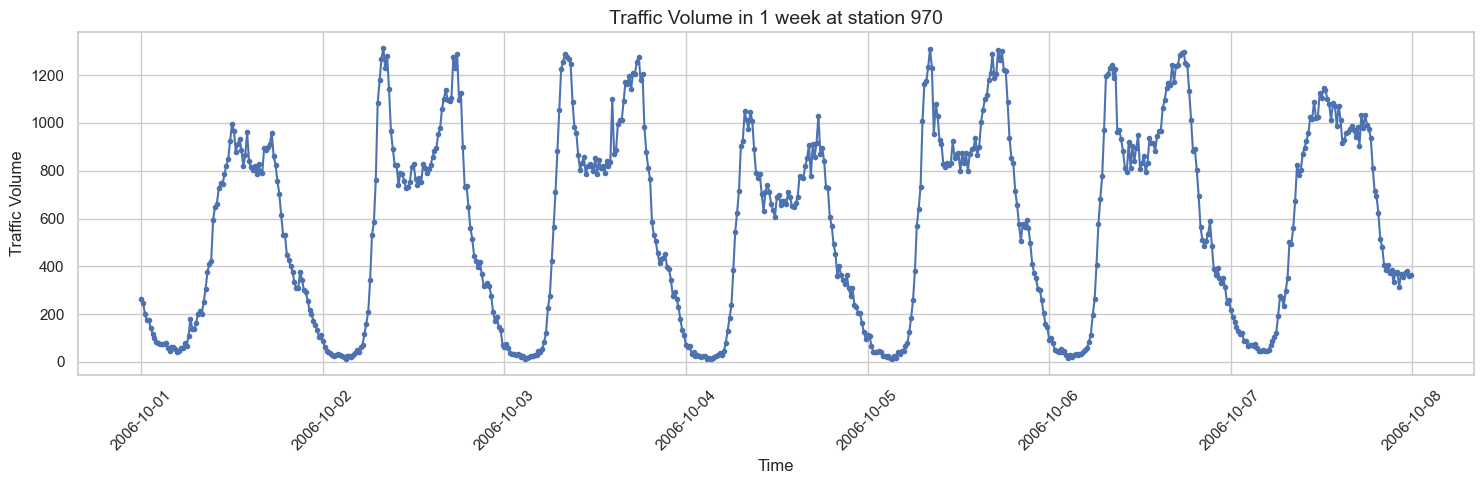

In [16]:
# Plot time series of 1 station in first 1 week
plt.figure(figsize=(15, 5))
sample_scats = df_long['SCATS_ID'].unique()[0] # Take first station as example
sample_data = df_long[(df_long['SCATS_ID'] == sample_scats) & 
                      (df_long['Timestamp'] < df_long['Timestamp'].min() + pd.Timedelta(days=7))]

plt.plot(sample_data['Timestamp'], sample_data['Traffic_Volume'], marker='.', linestyle='-')
plt.title(f'Traffic Volume in 1 week at station {sample_scats}', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- **Daily Patterns**: Peaks in morning and evening, low at night.
- **Weekly Trends**: More traffic on weekdays than weekends.
- **Data Quality**: 15-minute intervals show detailed changes.
- **Modeling Insights**: Confirms need for time-series models.

This plot serves as a sanity check for the data transformation and provides initial insights into traffic behavior at this station.

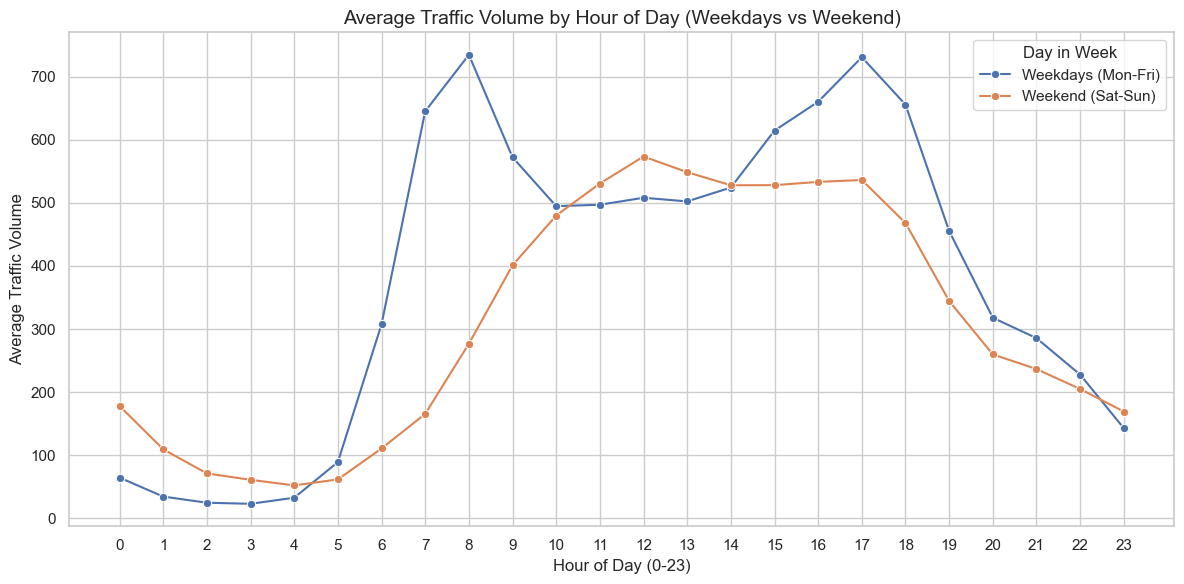

In [17]:
# Compare traffic pattern Weekdays vs Weekend by Hour
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_long, x='hour_of_day', y='Traffic_Volume', hue='is_weekend', errorbar=None, marker='o')
plt.title('Average Traffic Volume by Hour of Day (Weekdays vs Weekend)', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Traffic Volume')
plt.legend(title='Day in Week', labels=['Weekdays (Mon-Fri)', 'Weekend (Sat-Sun)'])
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

- **Rush Hours**: Higher peaks on weekdays during morning (7-9 AM) and evening (4-7 PM).
- **Weekend Patterns**: More even traffic throughout the day, lower overall volume.
- **Daily Variations**: Clear differences between weekday and weekend traffic behavior.
- **Modeling Insights**: Highlights the importance of time features like hour and weekend indicators.

This plot helps understand temporal patterns across the week.

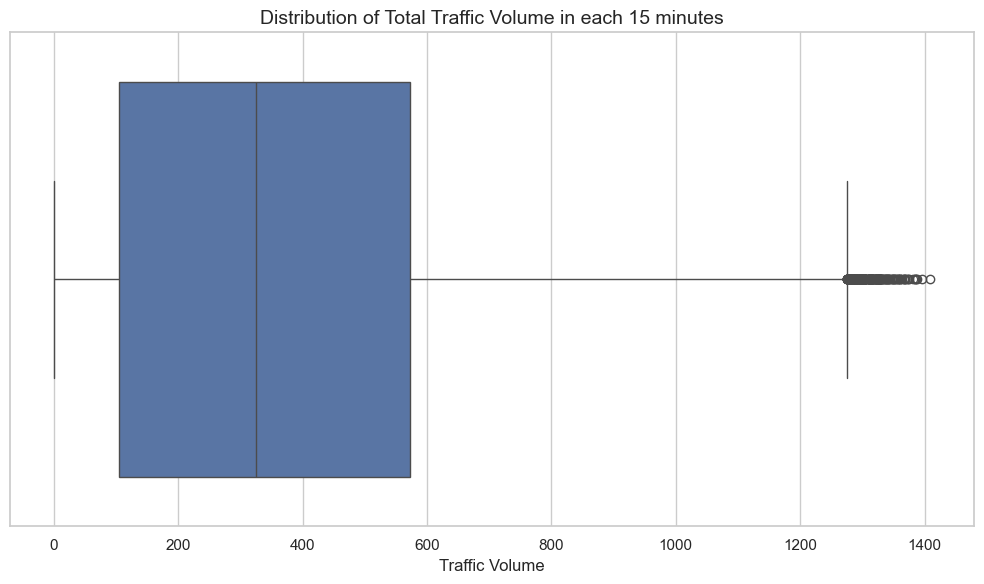

In [18]:
# Data distribution (Boxplot) to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_long['Traffic_Volume'])
plt.title('Distribution of Total Traffic Volume in each 15 minutes', fontsize=14)
plt.xlabel('Traffic Volume')
plt.tight_layout()
plt.show()

- **Central Tendency**: Median traffic volume around typical levels.
- **Spread**: Wide range with significant variability across 15-minute intervals.
- **Outliers**: Presence of high-volume outliers indicates peak traffic events.
- **Modeling Insights**: Suggests robust scaling and outlier handling for better predictions.

This plot highlights data variability and informs preprocessing steps.

## Step 5: Sequence Creation

This section builds sliding-window sequences for sequence models (LSTM/GRU) from the long-format dataframe.

### Sliding window approach
- **Window size**: 12 timesteps (3 hours × 15‑minute intervals)
- **Per-site processing**: sequences are created separately for each `SCATS_ID`
- **Chronological split**: train/validation/test are split in time order within each site (default 70% / 15% / 15%)

### Features per timestep
- `Traffic_Volume` (scaled) plus time features: `day_of_week`, `hour_of_day`, `is_weekend`, `is_rush_hour`, `is_night`

### Scaling
- LSTM: a single `MinMaxScaler` is fitted using **training volumes only** and applied to `Traffic_Volume` before sequence creation.
- GRU: separate scalers are produced for input/output in the later GRU section.

**Output**: `X_*` arrays shaped like `(samples, 12, num_features)` and `y_*` labels for the next timestep's traffic volume.

In [19]:
def create_lstm_sequences_and_scale(df_long, seq_length=12, train_ratio=0.7, val_ratio=0.15):
    """
    Create sliding window data for LSTM model.
    Divide Train/Val/Test sets chronologically for EACH station so the model is not 'blind' to data from stations at the end.
    Fits a scaler on the training data to scales the target variable (Traffic_Volume).
    """
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []
    
    train_volumes = []
    for scats_id, group in df_long.groupby('SCATS_ID'):
        group = group.sort_values('Timestamp')
        n = len(group)
        train_end = int(n * train_ratio)
        train_volumes.extend(group['Traffic_Volume'].iloc[:train_end].values)
    
    scaler = MinMaxScaler()
    scaler.fit(np.array(train_volumes).reshape(-1, 1))
    df_scaled_long = df_long.copy()
    df_scaled_long['Traffic_Volume'] = scaler.transform(df_scaled_long['Traffic_Volume'].values.reshape(-1, 1))
    
    # Note: Get all features. Prediction variable (y) is in first column (Traffic_Volume)
    feature_cols = ['Traffic_Volume', 'day_of_week', 'hour_of_day', 'is_weekend', 'is_rush_hour', 'is_night']
    
    # Must not create bridging sliding windows:
    # iterate through each data group of each SCATS_ID cluster
    for scats_id, group in df_scaled_long.groupby('SCATS_ID'):
        # Sort again to ensure correct chronological order
        group = group.sort_values('Timestamp')
        
        # Extract entire feature matrix
        data_values = group[feature_cols].values
        
        n = len(data_values)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        
        # Create sliding window with seq_length size
        for i in range(n - seq_length):
            x_seq = data_values[i : i + seq_length]
            y_target = data_values[i + seq_length, 0] # Take only column 0 (Traffic_Volume) as y_target
            target_idx = i + seq_length
            
            # Divide sets sequentially for each station
            if target_idx < train_end:
                X_train.append(x_seq)
                y_train.append(y_target)
            elif target_idx < val_end:
                X_val.append(x_seq)
                y_val.append(y_target)
            else:
                X_test.append(x_seq)
                y_test.append(y_target)
            
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_val, y_val = np.array(X_val), np.array(y_val)
    X_test, y_test = np.array(X_test), np.array(y_test)
    
    # Data is naturally 3D (samples, seq_length, features) so no need for expand_dims
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

X_train, y_train, X_val, y_val, X_test, y_test, scaler = create_lstm_sequences_and_scale(df_long)

print("\nData preparation for LSTM is completed!")
print(f" - Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f" - Validation set: X_val {X_val.shape}, y_val {y_val.shape}")
print(f" - Test set: X_test {X_test.shape}, y_test {y_test.shape}")


Data preparation for LSTM is completed!
 - Training set: X_train (80822, 12, 6), y_train (80822,)
 - Validation set: X_val (17411, 12, 6), y_val (17411,)
 - Test set: X_test (17447, 12, 6), y_test (17447,)


- **Sequence Creation**: Builds 12-step sliding windows per SCATS station for LSTM input.
- **Train/Val/Test Split**: Splits data chronologically within each station to avoid leakage.
- **Scaling**: Fits the scaler only on training volumes, then applies it to the full dataset.
- **Modeling Insights**: Prepares data for time-series modeling using both traffic and time-of-day features.

This step confirms that the LSTM inputs are ready and that the split preserves temporal order.

In [20]:
def create_gru_sequence_and_scale(df_long, sequence_length=12, train_ratio=0.7, val_ratio=0.15):
    """
    Combined scaling and sequencing for GRU model.
    Scale features (0-1) and create sliding windows.
    Returns: X_train, y_train, X_val, y_val, X_test, y_test, scaler_x, scaler_y
    """
    
    # Define the features used for each timestep in the GRU input
    feature_columns = ['Traffic_Volume', 'day_of_week', 'hour_of_day', 'is_weekend', 'is_rush_hour', 'is_night']

    # Build a training-only dataframe for scaler fitting to avoid data leakage
    train_indices = []
    for scats_id, group in df_long.groupby('SCATS_ID'):
        n = len(group)
        train_end = int(n * train_ratio)
        train_indices.extend(group.index[:train_end])  # collect training rows per station
    
    train_df = df_long.loc[train_indices]  # use .loc to preserve index labels and row selection
    
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    # Fit scalers on training data only
    scaler_x.fit(train_df[feature_columns])
    scaler_y.fit(train_df[['Traffic_Volume']])

    # Apply the fitted feature scaler to all rows for later sequence generation
    df_scaled = df_long.copy()
    df_scaled[feature_columns] = scaler_x.transform(df_long[feature_columns])

    # Prepare lists to collect the generated sequences
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    
    # Create sliding windows separately for each station to keep sequences contiguous
    for scats_id, group in df_scaled.groupby('SCATS_ID'):
        group = group.sort_values('Timestamp')
        data_values = group[feature_columns].values

        n = len(data_values)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        # Slide a window of `sequence_length` over the station's time series
        for i in range(n - sequence_length):
            x_sequence = data_values[i : i + sequence_length]
            y_target = data_values[i + sequence_length, 0]  # future traffic volume at next step

            target_index = i + sequence_length

            # Assign the sequence to train/val/test based on the target timestep index
            if target_index < train_end:
                X_train.append(x_sequence)
                y_train.append(y_target)
            elif target_index < val_end:
                X_val.append(x_sequence)
                y_val.append(y_target)
            else:
                X_test.append(x_sequence)
                y_test.append(y_target)

    return (np.array(X_train), np.array(y_train), 
        np.array(X_val), np.array(y_val), 
        np.array(X_test), np.array(y_test), 
        scaler_x, scaler_y)

X_train_gru, y_train_gru, X_val_gru, y_val_gru, X_test_gru, y_test_gru, scaler_x, scaler_y = create_gru_sequence_and_scale(df_long)

print("\nData preparation for GRU is completed!")
print(f" - Training set: X_train {X_train_gru.shape}, y_train {y_train_gru.shape}")
print(f" - Validation set: X_val {X_val_gru.shape}, y_val {y_val_gru.shape}")
print(f" - Test set: X_test {X_test_gru.shape}, y_test {y_test_gru.shape}")



Data preparation for GRU is completed!
 - Training set: X_train (80822, 12, 6), y_train (80822,)
 - Validation set: X_val (17411, 12, 6), y_val (17411,)
 - Test set: X_test (17447, 12, 6), y_test (17447,)


- **Sequence Creation**: Generates 12-step sliding windows for each station, ready for GRU input.
- **Train/Val/Test Split**: Uses chronological train/validation/test split per station to avoid information leakage.
- **Scaling**: Applies scaler trained on training data to all features, including traffic volume.
- **Modeling Insights**: Prepares a full time-series feature set with traffic and temporal indicators for GRU training.

This step verifies the GRU dataset is prepared properly for sequence modeling.

## Step 6: Export Preprocessed Data

This final section exports the preprocessed datasets and scalers to disk for reuse in training and inference.

### Exported files
- **LSTM dataset**: `preprocessed_data_lstm.pkl` containing `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`, and `df_long`
- **LSTM scaler**: `lstm_scaler.pkl` containing the fitted MinMaxScaler for LSTM traffic volume scaling
- **GRU dataset**: `preprocessed_data_gru.pkl` containing GRU train/val/test arrays and `df_long`
- **GRU scalers**: `gru_scaler.pkl` containing `scaler_x` and `scaler_y`

In [21]:
# Export preprocessed data to a single pickle file
lstm_output_file = "../data/preprocessed/preprocessed_data_lstm.pkl"
gru_output_file = "../data/preprocessed/preprocessed_data_gru.pkl"

lstm_preprocessed_data = {
    "X_train": X_train, "y_train": y_train,
    "X_val": X_val, "y_val": y_val,
    "X_test": X_test, "y_test": y_test,
    "df_long": df_long
}

gru_preprocessed_data = {
    "X_train": X_train_gru, "y_train": y_train_gru,
    "X_val": X_val_gru, "y_val": y_val_gru,
    "X_test": X_test_gru, "y_test": y_test_gru,
    "df_long": df_long
}

pickle.dump(lstm_preprocessed_data, open(lstm_output_file, "wb"))
print(f"All preprocessed LSTM data are exported to '{lstm_output_file}'")
joblib.dump(scaler, "../models/lstm/lstm_scaler.pkl")
print(f"LSTM scaler are exported to '../models/lstm/lstm_scaler.pkl'")

pickle.dump(gru_preprocessed_data, open(gru_output_file, "wb"))
print(f"All preprocessed GRU data are exported to '{gru_output_file}'")
gru_scaler = {"scaler_x": scaler_x, "scaler_y": scaler_y}
joblib.dump(gru_scaler, "../models/gru/gru_scaler.pkl")
print(f"GRU scaler (x and y) are exported to '../models/gru/gru_scaler.pkl'")

All preprocessed LSTM data are exported to '../data/preprocessed/preprocessed_data_lstm.pkl'
LSTM scaler are exported to '../models/lstm/lstm_scaler.pkl'
All preprocessed GRU data are exported to '../data/preprocessed/preprocessed_data_gru.pkl'
GRU scaler (x and y) are exported to '../models/gru/gru_scaler.pkl'
